In [1]:
%%capture
!pip install torch

In [16]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

#Tensor

In [3]:
#Define tensors with two possible ways
tensor1=torch.IntTensor([1, 2, 3])
tensor2 =torch.tensor([1, 2, 3], dtype=torch.int)

print(tensor1 , tensor2)

tensor([1, 2, 3], dtype=torch.int32) tensor([1, 2, 3], dtype=torch.int32)


In [4]:

heights = [189, 170, 189, 163, 183, 171, 185,
           168, 173, 183, 173, 173, 175, 178,
           183, 193, 178, 173, 174, 183, 183,
           180, 168, 180, 170, 178, 182, 180,
           183, 178, 182, 188, 175, 179, 183,
           193, 182, 183, 177, 185, 188, 188,
           182, 185, 191, 183]

heights_tensor = torch.tensor(heights,
           dtype=torch.float64)

height = heights_tensor[2]
print(height)

height = heights_tensor[-2]
print(height)

tensor(189., dtype=torch.float64)
tensor(191., dtype=torch.float64)


In [5]:
print(heights_tensor.shape)

torch.Size([46])


In [6]:
heights_in_feet = heights_tensor / 30.48
print(heights_in_feet)

tensor([6.2008, 5.5774, 6.2008, 5.3478, 6.0039, 5.6102, 6.0696, 5.5118, 5.6759,
        6.0039, 5.6759, 5.6759, 5.7415, 5.8399, 6.0039, 6.3320, 5.8399, 5.6759,
        5.7087, 6.0039, 6.0039, 5.9055, 5.5118, 5.9055, 5.5774, 5.8399, 5.9711,
        5.9055, 6.0039, 5.8399, 5.9711, 6.1680, 5.7415, 5.8727, 6.0039, 6.3320,
        5.9711, 6.0039, 5.8071, 6.0696, 6.1680, 6.1680, 5.9711, 6.0696, 6.2664,
        6.0039], dtype=torch.float64)


In [10]:
heights_2_measures = torch.cat( [heights_tensor,heights_in_feet], dim=0)
print(heights_2_measures)

tensor([189.0000, 170.0000, 189.0000, 163.0000, 183.0000, 171.0000, 185.0000,
        168.0000, 173.0000, 183.0000, 173.0000, 173.0000, 175.0000, 178.0000,
        183.0000, 193.0000, 178.0000, 173.0000, 174.0000, 183.0000, 183.0000,
        180.0000, 168.0000, 180.0000, 170.0000, 178.0000, 182.0000, 180.0000,
        183.0000, 178.0000, 182.0000, 188.0000, 175.0000, 179.0000, 183.0000,
        193.0000, 182.0000, 183.0000, 177.0000, 185.0000, 188.0000, 188.0000,
        182.0000, 185.0000, 191.0000, 183.0000,   6.2008,   5.5774,   6.2008,
          5.3478,   6.0039,   5.6102,   6.0696,   5.5118,   5.6759,   6.0039,
          5.6759,   5.6759,   5.7415,   5.8399,   6.0039,   6.3320,   5.8399,
          5.6759,   5.7087,   6.0039,   6.0039,   5.9055,   5.5118,   5.9055,
          5.5774,   5.8399,   5.9711,   5.9055,   6.0039,   5.8399,   5.9711,
          6.1680,   5.7415,   5.8727,   6.0039,   6.3320,   5.9711,   6.0039,
          5.8071,   6.0696,   6.1680,   6.1680,   5.9711,   6.06

In [15]:
print(torch.median(heights_tensor[0:]))
print(torch.mean(heights_tensor[0:]))

tensor(182., dtype=torch.float64)
tensor(180.0652, dtype=torch.float64)


#**Lets dive to DP in PyTorch**

##Loading, Demostrating and Preprocessing Data

In [18]:
torch.manual_seed(42)

transform=T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])

train_set=torchvision.datasets.FashionMNIST(
    root=".",
    train=True,
    download=True,
    transform=transform)

test_set=torchvision.datasets.FashionMNIST(
    root=".",
    train=False,
    download=True,
    transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.35MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.74MB/s]


In [19]:
text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

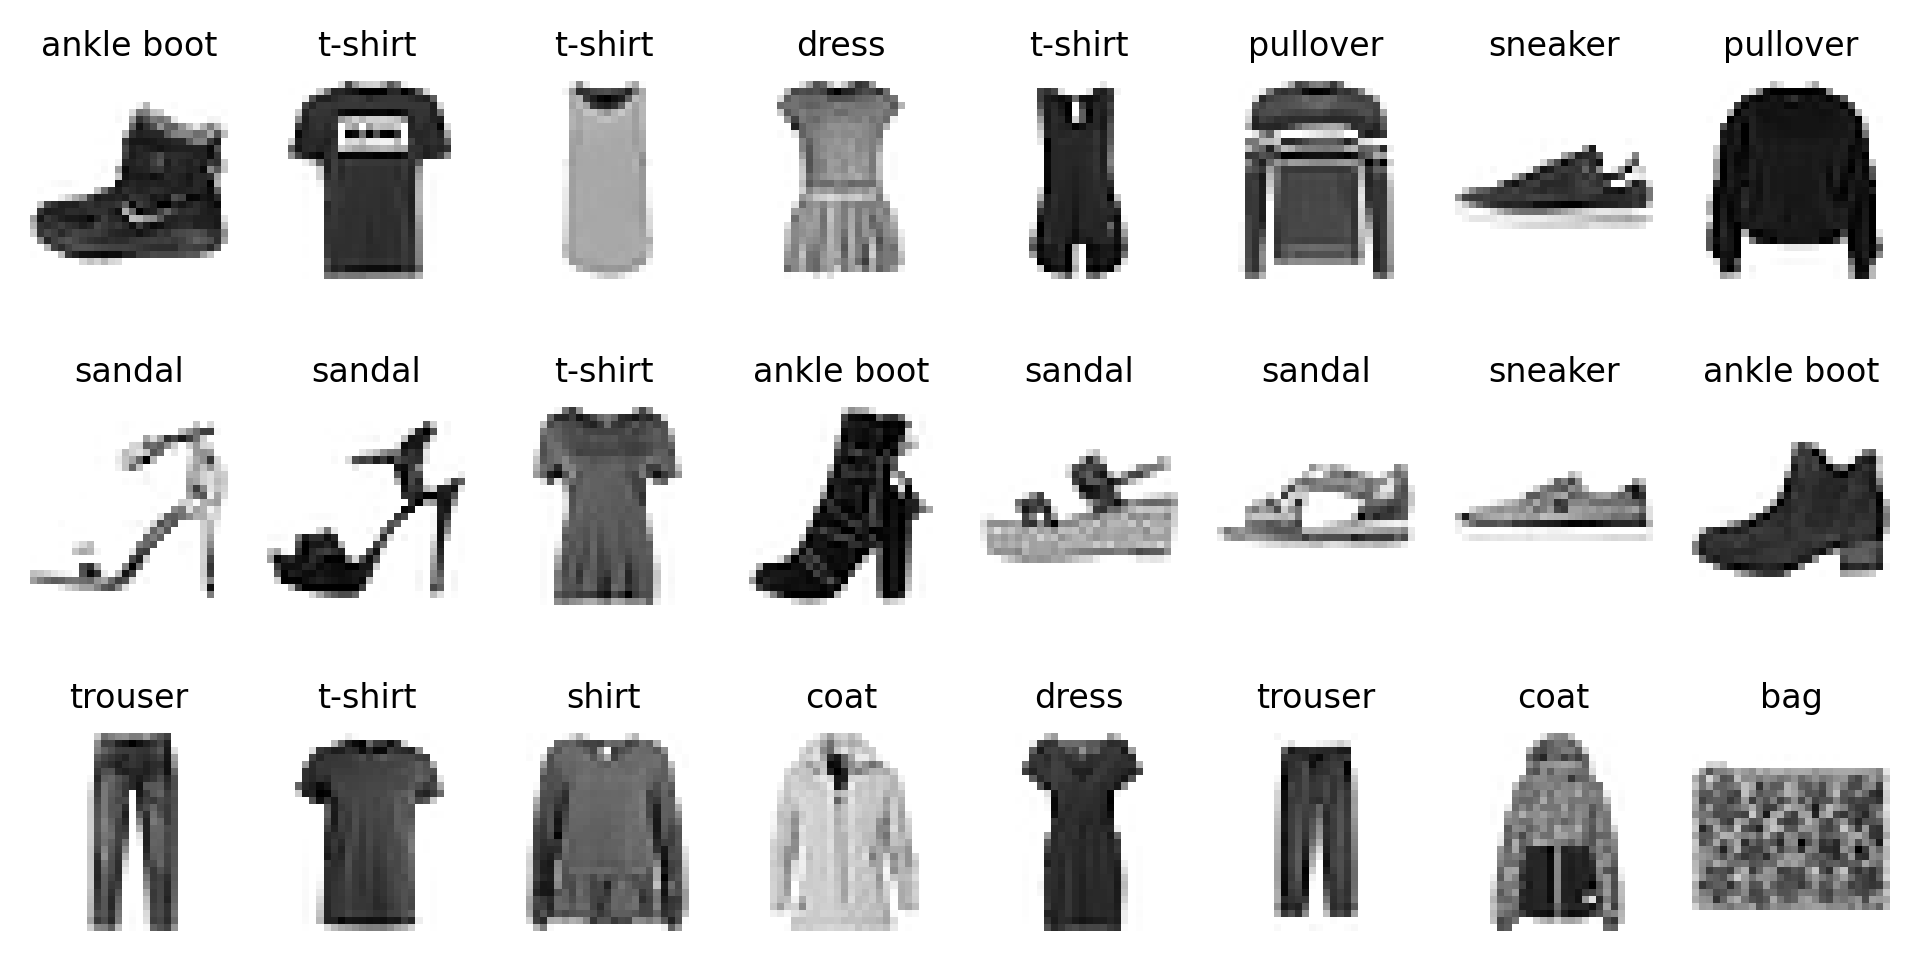

In [20]:
import matplotlib.pyplot as plt

plt.figure(dpi=300,figsize=(8,4))
for i in range(24):
    ax=plt.subplot(3, 8, i + 1)
    img=train_set[i][0]
    img=img/2+0.5
    img=img.reshape(28, 28)

    plt.imshow(img, cmap="binary")
    plt.axis('off')
    plt.title(text_labels[train_set[i][1]], fontsize=8)
plt.show()

In [21]:
binary_train_set = [x for x in train_set if x[1] in [0,9]]
binary_test_set = [x for x in test_set if x[1] in [0,9]]

batch_size=64
binary_train_loader=torch.utils.data.DataLoader(
    binary_train_set,
    batch_size=batch_size,
    shuffle=True)

binary_test_loader=torch.utils.data.DataLoader(
    binary_test_set,
    batch_size=batch_size,
    shuffle=True)

##Binary Classifier Network

In [22]:
device="cuda" if torch.cuda.is_available() else "cpu"

# Define a simple binary classification model using a sequential network
binary_model=nn.Sequential(
    # First fully connected layer: transforms the 28*28 input features (784) to 256 features.
    # This layer learns a linear transformation of the input data.
    nn.Linear(28*28,256),
    # ReLU (Rectified Linear Unit) activation function: introduces non-linearity to the model,
    # allowing it to learn complex patterns. It outputs the input if it's positive, otherwise 0.
    nn.ReLU(),
    # Second fully connected layer: reduces the feature size from 256 to 128.
    nn.Linear(256,128),
    # Another ReLU activation function for non-linearity.
    nn.ReLU(),
    # Third fully connected layer: further reduces the feature size from 128 to 32.
    nn.Linear(128,32),
    # Another ReLU activation function for non-linearity.
    nn.ReLU(),
    # Output layer: reduces the feature size to 1, which is suitable for binary classification.
    nn.Linear(32,1),
    # Dropout layer: randomly sets a fraction of the input units to 0 at each update during training
    # to help prevent overfitting. Here, 25% of the units are dropped.
    nn.Dropout(p=0.25),
    # Sigmoid activation function: squashes the output of the last linear layer to a value between 0 and 1.
    # This output can be interpreted as the probability of the input belonging to the positive class.
    nn.Sigmoid()).to(device)

In [23]:
lr=0.001
optimizer=torch.optim.Adam(binary_model.parameters(),lr=lr)
loss_fn=nn.BCELoss()
epochs = 50

In [24]:
# Loop through the training data for 50 epochs
for i in range(epochs):
    # Initialize the total loss for the current epoch
    tloss=0
    # Iterate through batches of images and labels from the training loader
    for n,(imgs,labels) in enumerate(binary_train_loader):

        # Preparing data to passing it to model
        # Reshape the images from 28x28 to a flattened vector of 784
        imgs=imgs.reshape(-1,28*28)
        # Move the images to the appropriate device (CPU or GPU)
        imgs=imgs.to(device)
        # Convert labels to FloatTensor and map original labels (0 and 9) to 0 and 1
        labels=torch.FloatTensor([x if x==0 else 1 for x in labels])
        # Reshape labels to (batch_size, 1) and move to the device
        labels=labels.reshape(-1,1).to(device)

        # Forward pass: get predictions from the model
        preds=binary_model(imgs)
        # Calculate the loss between predictions and actual labels
        loss=loss_fn(preds,labels)

        # Backward pass: calculate gradients and update model parameters
        # Clear previous gradients
        optimizer.zero_grad()
        # Compute gradients of the loss with respect to model parameters
        loss.backward()
        # Update model parameters using the optimizer
        optimizer.step()
        # Accumulate the loss for the current batch
        tloss+=loss

    # Calculate the average loss for the epoch
    tloss=tloss/n
    # Print the loss for the current epoch
    print(f"at epoch {i}, loss is {tloss}")

at epoch 0, loss is 0.19452261924743652
at epoch 1, loss is 0.17840902507305145
at epoch 2, loss is 0.1786920428276062
at epoch 3, loss is 0.17876285314559937
at epoch 4, loss is 0.17200784385204315
at epoch 5, loss is 0.17734919488430023
at epoch 6, loss is 0.17772690951824188
at epoch 7, loss is 0.17568731307983398
at epoch 8, loss is 0.17402999103069305
at epoch 9, loss is 0.1743689924478531
at epoch 10, loss is 0.17624643445014954
at epoch 11, loss is 0.17838695645332336
at epoch 12, loss is 0.17074033617973328
at epoch 13, loss is 0.17214743793010712
at epoch 14, loss is 0.18018169701099396
at epoch 15, loss is 0.17763088643550873
at epoch 16, loss is 0.17178134620189667
at epoch 17, loss is 0.170217826962471
at epoch 18, loss is 0.17340309917926788
at epoch 19, loss is 0.1737503856420517
at epoch 20, loss is 0.17120207846164703
at epoch 21, loss is 0.17004363238811493
at epoch 22, loss is 0.1742715835571289
at epoch 23, loss is 0.17913657426834106
at epoch 24, loss is 0.172765642

In [25]:
results=[]
for imgs,labels in binary_test_loader:

    imgs=imgs.reshape(-1,28*28).to(device)
    labels=torch.FloatTensor([x if x==0 else 1 for x in labels])
    labels=(labels).reshape(-1,1).to(device)

    preds=binary_model(imgs)
    pred10=torch.where(preds>0.5,1,0)
    correct=(pred10==labels)
    results.append(correct.detach().cpu()\
      .numpy().mean())    #C
accuracy=np.array(results).mean()    #D
print(f"the accuracy of the predictions is {accuracy}")

the accuracy of the predictions is 0.880859375


#Multi-dim Classificiton

In [26]:
torch.manual_seed(42)

train_set,val_set=torch.utils.data.random_split(train_set,[50000,10000])

train_loader=torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True)

val_loader=torch.utils.data.DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=True)

test_loader=torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=True)

In [27]:
# Define a class for Early Stopping
class EarlyStop:
    # Initialize the EarlyStop object
    def __init__(self, patience=10):
        # Set the patience parameter, which is the number of epochs to wait for improvement
        self.patience = patience
        # Initialize the steps counter to 0
        self.steps = 0
        # Initialize the minimum validation loss to infinity
        self.min_loss = float('inf')
    # Define the stop method to check if early stopping criteria are met
    def stop(self, val_loss):
        # If the current validation loss is less than the minimum loss seen so far
        if val_loss < self.min_loss:
            # Update the minimum loss
            self.min_loss = val_loss
            # Reset the steps counter
            self.steps = 0
        # If the current validation loss is greater than or equal to the minimum loss
        elif val_loss >= self.min_loss:
            # Increment the steps counter
            self.steps += 1

        if self.steps >= self.patience:
            return True
        else:
            return False

# Create an instance of the EarlyStop class with default patience (10)
stopper=EarlyStop()

In [28]:
# Define a sequential model for multi-class classification
model=nn.Sequential(
    # First linear layer: transforms the input features (28*28 = 784) to 256 features.
    # This layer learns a linear combination of the input pixels.
    nn.Linear(28*28,256),
    # ReLU activation function: introduces non-linearity after the first linear layer.
    nn.ReLU(),
    # Second linear layer: transforms the 256 features to 128 features.
    nn.Linear(256,128),
    # ReLU activation function: introduces non-linearity after the second linear layer.
    nn.ReLU(),
    # Third linear layer: transforms the 128 features to 64 features.
    nn.Linear(128,64),
    # ReLU activation function: introduces non-linearity after the third linear layer.
    nn.ReLU(),
    # Output linear layer: transforms the 64 features to 10 features, corresponding to the 10 classes
    # in the FashionMNIST dataset. The output of this layer will be used to calculate class probabilities.
    nn.Linear(64,10)).to(device)

In [29]:
lr=0.001
optimizer=torch.optim.Adam(model.parameters(),lr=lr)
loss_fn=nn.CrossEntropyLoss()

In [31]:
def train_epoch():
    tloss=0
    for n,(imgs,labels) in enumerate(train_loader):
        imgs=imgs.reshape(-1,28*28).to(device)
        labels=labels.reshape(-1,).to(device)
        preds=model(imgs)
        loss=loss_fn(preds,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tloss+=loss
    return tloss/n



def val_epoch():
    vloss=0
    for n,(imgs,labels) in enumerate(val_loader):
        imgs=imgs.reshape(-1,28*28).to(device)
        labels=labels.reshape(-1,).to(device)
        preds=model(imgs)
        loss=loss_fn(preds,labels)
        vloss+=loss
    return vloss/n

In [32]:
for i in range(1,101):
    tloss=train_epoch()
    vloss=val_epoch()
    print(f"at epoch {i}, tloss is {tloss}, vloss is {vloss}")
    if stopper.stop(vloss)==True:
        print("Corss Entropy Algorithm have decleared that this is the stopping point where we are approaching to overfit!")
        break

at epoch 1, tloss is 0.5381468534469604, vloss is 0.409934401512146
at epoch 2, tloss is 0.3846866488456726, vloss is 0.40623968839645386
at epoch 3, tloss is 0.3453591465950012, vloss is 0.38351869583129883
at epoch 4, tloss is 0.32199013233184814, vloss is 0.34563952684402466
at epoch 5, tloss is 0.30197128653526306, vloss is 0.33754244446754456
at epoch 6, tloss is 0.28259655833244324, vloss is 0.3229639232158661
at epoch 7, tloss is 0.26843973994255066, vloss is 0.3277711570262909
at epoch 8, tloss is 0.255127876996994, vloss is 0.3256150782108307
at epoch 9, tloss is 0.24502010643482208, vloss is 0.3224211037158966
at epoch 10, tloss is 0.2338329255580902, vloss is 0.3318411409854889
at epoch 11, tloss is 0.22462144494056702, vloss is 0.3361146152019501
at epoch 12, tloss is 0.21793316304683685, vloss is 0.35722002387046814
at epoch 13, tloss is 0.20756013691425323, vloss is 0.3454549312591553
at epoch 14, tloss is 0.1971786618232727, vloss is 0.3352918326854706
at epoch 15, tloss

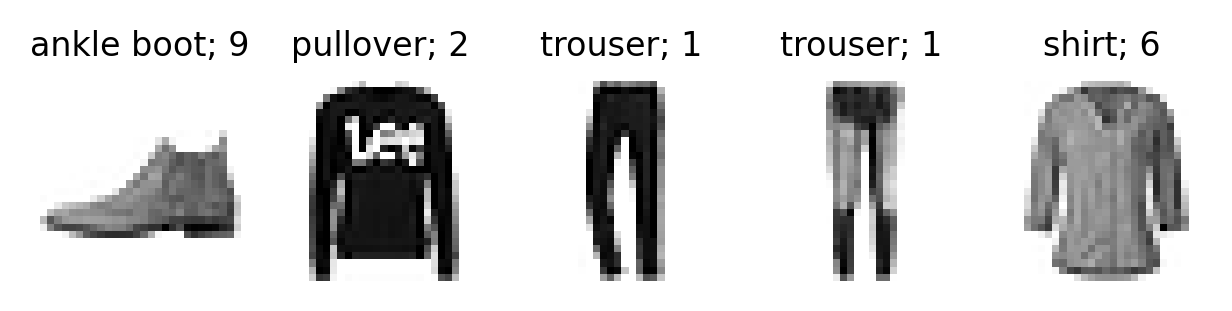

the label is 9; the prediction is 9
the label is 2; the prediction is 2
the label is 1; the prediction is 1
the label is 1; the prediction is 1
the label is 6; the prediction is 6


In [33]:
plt.figure(dpi=300,figsize=(5,1))

for i in range(5):
    ax=plt.subplot(1,5, i + 1)
    img=test_set[i][0]
    label=test_set[i][1]
    img=img/2+0.5
    img=img.reshape(28, 28)
    plt.imshow(img, cmap="binary")
    plt.axis('off')
    plt.title(text_labels[label]+f"; {label}", fontsize=8)
plt.show()
for i in range(5):
    img,label = test_set[i]
    img=img.reshape(-1,28*28).to(device)
    pred=model(img)
    index_pred=torch.argmax(pred,dim=1)
    idx=index_pred.item()
    print(f"the label is {label}; the prediction is {idx}")

In [34]:
results=[]

for imgs,labels in test_loader:
    imgs=imgs.reshape(-1,28*28).to(device)
    labels=(labels).reshape(-1,).to(device)
    preds=model(imgs)
    pred10=torch.argmax(preds,dim=1)
    correct=(pred10==labels)
    results.append(correct.detach().cpu().numpy().mean())

accuracy=np.array(results).mean()

print(f"the accuracy of the predictions is {accuracy}")

the accuracy of the predictions is 0.884156050955414
